In [1]:
pip install gwaslab 


Defaulting to user installation because normal site-packages is not writeable


Note: you may need to restart the kernel to use updated packages.


In [1]:
import gwaslab as gl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load gwas data

In [2]:
import pandas as pd
import gzip

file_path = "../../data/susie/UK_Biobank/body_BMIz.sumstats.gz"
with gzip.open(file_path, 'rt') as f:
    gwas_data_df = pd.read_csv(f, sep='\t') 

In [10]:
gwas_data_df.head()

,SNP,CHR,POS,A1,A2,REF,EAF,Beta,se,P,N,INFO
0,rs10399793,1,49298,T,C,T,0.376221,0.000796,0.003386,0.88,457824,0.342797
1,rs2462492,1,54676,C,T,C,0.599405,-0.001348,0.003354,0.60,457824,0.340158
2,rs3107975,1,55326,T,C,T,0.991555,-0.009526,0.018691,0.52,457824,0.324228
3,rs74447903,1,57033,T,C,T,0.998221,-0.056146,0.041545,0.16,457824,0.296256
4,1:70728_C_T,1,70728,C,T,C,0.997833,-0.015430,0.033783,0.53,457824,0.365713


## Data Processing 

In [11]:
gwas_data_df["SNPID"] = gwas_data_df["CHR"].astype(str) + ":" + gwas_data_df["POS"].astype(str) + ":" + gwas_data_df["A1"] + ":" + gwas_data_df["A2"]


In [12]:
gwas_data_df.head()

,SNP,CHR,POS,A1,A2,REF,EAF,Beta,se,P,N,INFO,SNPID
0,rs10399793,1,49298,T,C,T,0.376221,0.000796,0.003386,0.88,457824,0.342797,1:49298:T:C
1,rs2462492,1,54676,C,T,C,0.599405,-0.001348,0.003354,0.60,457824,0.340158,1:54676:C:T
2,rs3107975,1,55326,T,C,T,0.991555,-0.009526,0.018691,0.52,457824,0.324228,1:55326:T:C
3,rs74447903,1,57033,T,C,T,0.998221,-0.056146,0.041545,0.16,457824,0.296256,1:57033:T:C
4,1:70728_C_T,1,70728,C,T,C,0.997833,-0.015430,0.033783,0.53,457824,0.365713,1:70728:C:T


## Minor Allele Frequency and Significant SNP Filtering 

In [13]:
significant_snp_df = gwas_data_df[gwas_data_df['P'] <= 5e-8]
significant_snp_df = significant_snp_df[~significant_snp_df['SNPID'].str.startswith('X:')]


In [14]:
significant_snp_df.to_csv("../../data/susie/UK_Biobank/BMI/significant_snps.csv", index=False)

## Extract Most significant variant snd Define region around the most significant SNP

In [15]:
variant_position = 53828066
start_pos = variant_position - 500000
end_pos = variant_position + 500000

region_snp_df = significant_snp_df[
    (significant_snp_df['CHR'] == 16) &
    (significant_snp_df['POS'] >= start_pos) &
    (significant_snp_df['POS'] <= end_pos)
]


In [16]:
chr16_53828066_region=region_snp_df

In [17]:
chr16_53828066_region.head()

,SNP,CHR,POS,A1,A2,REF,EAF,Beta,se,P,N,INFO,SNPID
10274778,rs4783812,16,53503110,C,G,C,0.975605,0.034024,0.006355,4.800000e-08,457824,0.948726,16:53503110:C:G
10274986,rs60380613,16,53555390,C,T,C,0.818314,-0.015106,0.002504,1.100000e-09,457824,0.984282,16:53555390:C:T
10274989,rs113465156,16,53555556,C,T,C,0.817637,-0.014838,0.002501,2.200000e-09,457824,0.983574,16:53555556:C:T
10274998,rs2892459,16,53556809,G,A,G,0.870781,0.015733,0.002874,3.300000e-08,457824,0.989479,16:53556809:G:A
10275002,rs74363623,16,53557212,G,A,G,0.870547,0.015879,0.002872,2.300000e-08,457824,0.988011,16:53557212:G:A


In [18]:
chr16_53828066_region["SNPID"].to_csv("../../data/susie/UK_Biobank/BMI/chr16_53828066_region_snplist.txt", index=False)

In [19]:
chr16_53828066_region.to_csv("../../data/susie/UK_Biobank/BMI/chr16_53828066_region.txt", index=False)

## RUN PLINK

In [106]:
!plink \
  --bfile "../../data/susie/plink_binary/merged_data" \
  --keep-allele-order \
  --r square \
  --extract ../../data/susie/UK_Biobank/BMI/chr16_53828066_region_snplist.txt \
  --out ../../data/susie/UK_Biobank/BMI/sig_locus_mt

!plink \
  --bfile "../../data/susie/plink_binary/merged_data" \
  --keep-allele-order \
  --r2 square \
  --extract ../../data/susie/UK_Biobank/BMI/chr16_53828066_region_snplist.txt \
  --out ../../data/susie/UK_Biobank/BMI/sig_locus_mt_r2

PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ../../data/susie/UK_Biobank/BMI/sig_locus_mt.log.
Options in effect:
  --bfile ../../data/susie/plink_binary/merged_data
  --extract ../../data/susie/UK_Biobank/BMI/chr16_53828066_region_snplist.txt
  --keep-allele-order
  --out ../../data/susie/UK_Biobank/BMI/sig_locus_mt
  --r square

257419 MB RAM detected; reserving 128709 MB for main workspace.
6622286 variants loaded from .bim file.
503 people (0 males, 0 females, 503 ambiguous) loaded from .fam.
Ambiguous sex IDs written to ../../data/susie/UK_Biobank/BMI/sig_locus_mt.nosex
.
--extract: 275 variants remaining.
Using up to 27 threads (change this with --threads).
Before main variant filters, 503 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596

## Finemapping

In [4]:

from rpy2.robjects.packages import importr
import rpy2.robjects as ro
import rpy2.robjects.numpy2ri as numpy2ri
import rpy2.robjects.pandas2ri as pandas2ri
import matplotlib.pyplot as plt
numpy2ri.activate()
pandas2ri.activate()

In [5]:
susieR = importr('susieR')

## Visualization of LD (Linkage Disequilibrium) Matrices

In [6]:
import pandas as pd
ld_r = pd.read_csv("../../data/susie/UK_Biobank/BMI/sig_locus_mt.ld", sep="\t", header=None)
R_df = ld_r.values
ld2 = pd.read_csv("../../data/susie/UK_Biobank/BMI/sig_locus_mt_r2.ld",sep="\t",header=None)
R_df2 = ld2.values
R_df.shape

(275, 275)

Text(0.5, 1.0, 'LD r2 matrix')

<Figure size 2000x2000 with 0 Axes>

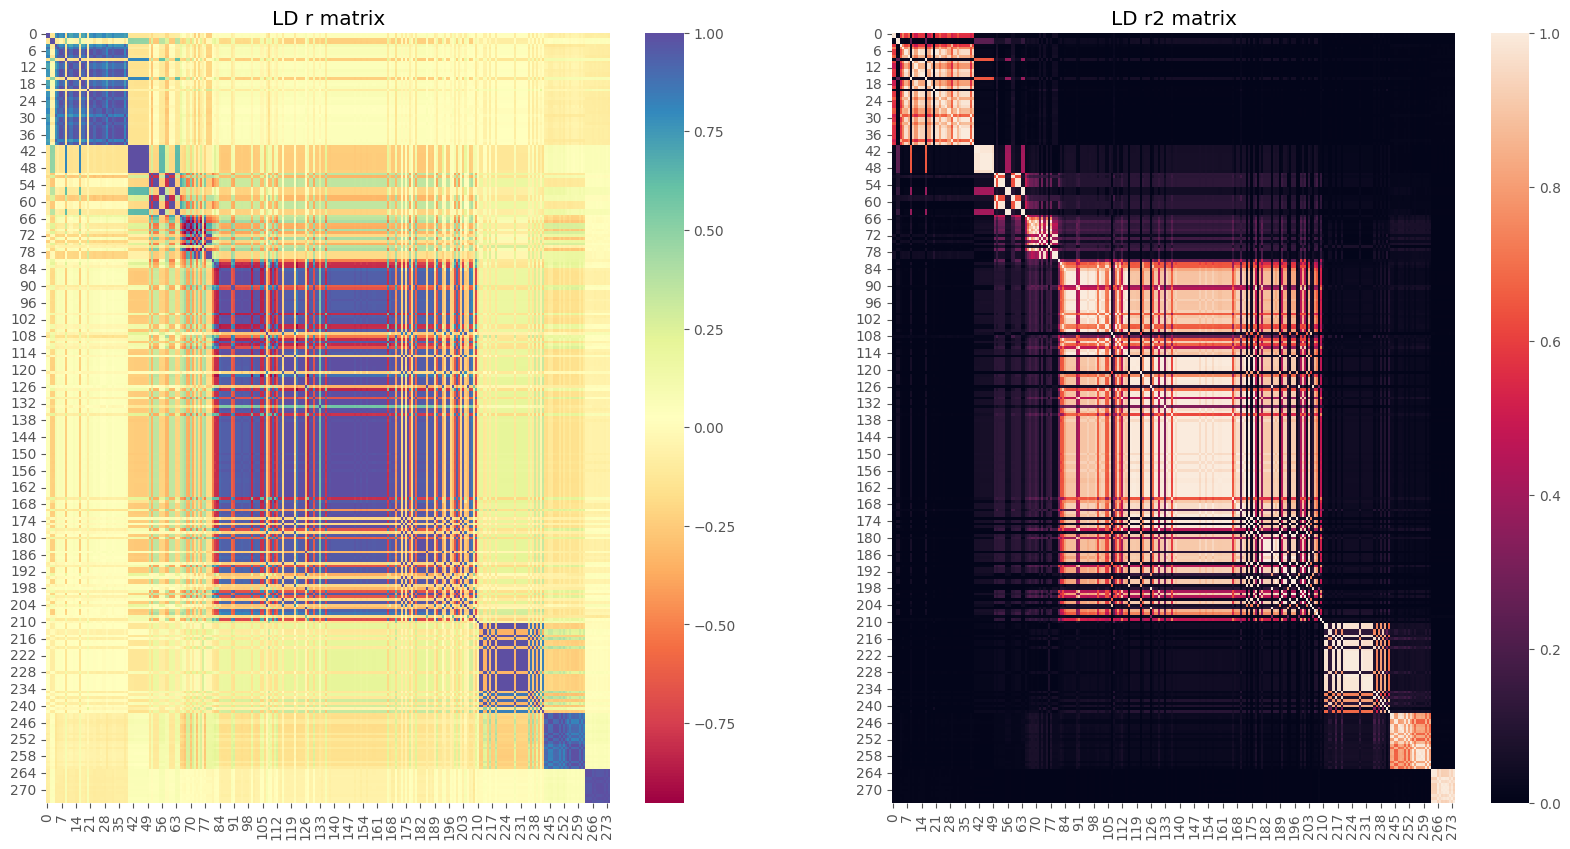

In [108]:
plt.figure(figsize=(10,10),dpi=200)
fig, ax = plt.subplots(ncols=2,figsize=(20,10))
sns.heatmap(data=R_df,cmap="Spectral",ax=ax[0])
sns.heatmap(data=R_df2,ax=ax[1])
ax[0].set_title("LD r matrix")
ax[1].set_title("LD r2 matrix")

In [7]:
chr16_53828066_region=pd.read_csv("../../data/susie/UK_Biobank/BMI/chr16_53828066_region.txt", sep="\t", header=None)

In [8]:
print(chr16_53828066_region.shape)
print(R_df.shape) 

(331, 1)
(275, 275)


## ISSUE:

From the plink result there are SNPS that are found in the gwas data(21001_raw.gwas.imputed_v3.both_sexes) which are missing from the vcf 1000 genomic population data. 

Inorder to see which snps are missing the method i used is

1.only store the SNP column that are found in the merged_data.bim(all chr plink binary files) to available_snps.txt
   `awk '{print $2}' ../data/susie/plink_binary/merged_data.bim > ../data/susie/plink_binary/available_snps.txt`

2. extract SNPs that are not common from the avaliable_snps and from the current chr16_pos53828066_snps.txt
`grep -vFf ../../data/susie/plink_binary/available_snps.txt ../../data/susie/UK_Biobank/BMI/chr16_53828066_region.txt > ../../data/susie/UK_Biobank/BMI/missing_snps.txt `


    SNPID   minor_allele    minor_AF        low_confidence_variant  n_complete_samples      AC      ytx     beta   se       tstat   P       CHR     POS     A2      A1
    16:53798630:C:CT        CT      0.115132        False   359983  82890.9 2260270.0       -0.155318       0.0176772       -8.78632        1.55203e-18     16      53798630        C       CT
    16:53799977:T:G G       0.421581        False   359983  303524.0        8371400.0       0.340303        0.0112735       30.1862 6.39588e-200    16      53799977        T       G
    16:53812783:TTTTG:T     T       0.390218        False   359983  280943.0        7751780.0       0.348645       0.01153  30.2382 1.33422e-200    16      53812783        TTTTG   T
    16:53820996:C:G G       0.392556        False   359983  282627.0        7799390.0       0.349687        0.0114009       30.6719 2.49515e-206    16      53820996        C       G

From the result there are total of `4` SNPs which are not included in the ld matrix.
The missing snps are also not found in the original vcf data before it is converted to plink binary files.

The current solution i used is to exclude these snps from the chr16_pos53828066_snps.txt so that to match the shape of the ld_matrix. 

In [20]:
missing_snps=pd.read_csv("../../data/susie/UK_Biobank/BMI/missing_snps.txt", delim_whitespace=False)
missing_snps.shape

/tmp/ipykernel_3243838/379248018.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  missing_snps=pd.read_csv("../../data/susie/UK_Biobank/BMI/missing_snps.txt", delim_whitespace=False)


(55, 13)

In [21]:
filtered_chr16_pos53828066_region = chr16_53828066_region[~chr16_53828066_region["POS"].isin(missing_snps["POS"])]

In [22]:
filtered_chr16_pos53828066_region.head(1)

,SNP,CHR,POS,A1,A2,REF,EAF,Beta,se,P,N,INFO,SNPID
10274986,rs60380613,16,53555390,C,T,C,0.818314,-0.015106,0.002504,1.100000e-09,457824,0.984282,16:53555390:C:T


## Run finemapping with susieR

In [23]:
print(R_df.shape)
print(filtered_chr16_pos53828066_region["Beta"].shape)
print(filtered_chr16_pos53828066_region["se"].shape)


(275, 275)
(275,)
(275,)


r-2

In [81]:
import pandas as pd
ld_r = pd.read_csv("../../data/susie/UK_Biobank/BMI/sig_locus_mt.ld", sep="\t", header=None)
R_df = ld_r.values
ld2 = pd.read_csv("../../data/susie/UK_Biobank/BMI/sig_locus_mt_r2.ld",sep="\t",header=None)
R_df2 = ld2.values
R_df.shape

(275, 275)

In [83]:
ro.r('set.seed(321)')
fit = susieR.susie_rss(
    bhat = filtered_chr16_pos53828066_region["Beta"].values.reshape(len(R_df), 1),
    shat = filtered_chr16_pos53828066_region["se"].values.reshape(len(R_df), 1),
    R = R_df,
    L = 10,
    n = 457824
)


 
                  Please check consistency between summary statistics and LD matrix.
                  See https://stephenslab.github.io/susieR/articles/susierss_diagnostic.html



## Adjusting the LD matrix to be positive semi-definite

In [26]:
eigvals = np.linalg.eigvalsh(R_df)
min_eigval = eigvals.min()
print(min_eigval)

-0.001768348459990833


In [58]:
if min_eigval < 0:
    eps = 1e-8
    R_df += np.eye(R_df.shape[0]) * eps


In [69]:
ro.r('set.seed(321)')
fit = susieR.susie_rss(
    bhat = filtered_chr16_pos53828066_region["Beta"].values.reshape(len(R_df), 1),
    shat = filtered_chr16_pos53828066_region["se"].values.reshape(len(R_df), 1),
    R = R_df,
    L = 10,
    n = 457824
)

## Extract credible sets and pip

In [70]:
credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)
print(credible_sets)

$cs
$cs$L1
[1] 111

$cs$L2
[1] 101 105

$cs$L3
[1] 123

$cs$L4
[1] 137

$cs$L5
[1]  96 100 103 104

$cs$L6
[1] 83

$cs$L7
[1] 85

$cs$L8
[1] 128

$cs$L9
[1] 168

$cs$L10
[1] 167


$purity
    min.abs.corr mean.abs.corr median.abs.corr
L1             1             1               1
L2             1             1               1
L3             1             1               1
L4             1             1               1
L5             1             1               1
L6             1             1               1
L7             1             1               1
L8             1             1               1
L9             1             1               1
L10            1             1               1

$cs_index
 [1]  1  2  3  4  5  6  7  8  9 10

$coverage
 [1] 1.000000 1.000000 1.000000 1.000000 0.994733 1.000000 1.000000 1.000000
 [9] 1.000000 1.000000

$requested_coverage
[1] 0.95




In [62]:
filtered_chr16_pos53828066_region = filtered_chr16_pos53828066_region.reset_index(drop=True)

In [72]:

filtered_chr16_pos53828066_region["cs"] = 0
n_cs = len(susieR.susie_get_cs(fit, coverage = 0.95, min_abs_corr = 0.5, Xcorr = R_df)[0])
print(n_cs)
credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)[0]

for i in range(n_cs):
    cs_index = credible_sets[i]
    filtered_chr16_pos53828066_region.loc[np.array(cs_index)-1, "cs"] = i + 1

filtered_chr16_pos53828066_region["pip"] = np.array(susieR.susie_get_pip(fit))

10


In [73]:
cs_index = np.array(credible_sets[0])
for i in range(1, n_cs):
    cs_index = np.concatenate((cs_index, np.array(credible_sets[i])), axis=0)
credible_snps = filtered_chr16_pos53828066_region.loc[cs_index - 1, :]

print(credible_snps)

            SNP  CHR       POS A1 A2 REF       EAF      Beta        se  \
110  rs56094641   16  53806453  A  G   A  0.595465 -0.075334  0.001955   
100   rs8055197   16  53803156  G  A   G  0.497692 -0.062291  0.001919   
104   rs1861866   16  53804340  C  T   C  0.497643 -0.062284  0.001919   
122   rs8057044   16  53812614  G  A   G  0.523471 -0.061732  0.001922   
136   rs3751813   16  53818708  G  T   G  0.455785 -0.058246  0.001928   
95    rs1421085   16  53800954  T  C   T  0.596652 -0.075341  0.001956   
99   rs11642015   16  53802494  C  T   C  0.596439 -0.075359  0.001956   
102  rs62048402   16  53803223  G  A   G  0.596460 -0.075350  0.001956   
103   rs1558902   16  53803574  T  A   T  0.596444 -0.075338  0.001956   
82    rs7206790   16  53797908  C  G   C  0.532387 -0.060096  0.001939   
84    rs8047587   16  53798622  G  T   G  0.560720 -0.070251  0.001936   
127  rs11075987   16  53815161  T  G   T  0.506704 -0.060050  0.001919   
167  rs62033406   16  53824226  A  G  

In [74]:
credible_snps_sorted = credible_snps.sort_values(by="pip", ascending=False)
print(credible_snps_sorted[["SNPID", "pip"]])

               SNPID       pip
110  16:53806453:A:G  1.000000
122  16:53812614:G:A  1.000000
136  16:53818708:G:T  1.000000
127  16:53815161:T:G  1.000000
167  16:53824226:A:G  1.000000
82   16:53797908:C:G  1.000000
166  16:53824007:G:A  1.000000
84   16:53798622:G:T  1.000000
100  16:53803156:G:A  0.540026
104  16:53804340:C:T  0.459974
99   16:53802494:C:T  0.354360
102  16:53803223:G:A  0.245068
95   16:53800954:T:C  0.228104
103  16:53803574:T:A  0.167201


In [78]:
import requests


chrom =credible_snps_sorted["CHR"]
pos =credible_snps_sorted["POS"]
pip =credible_snps_sorted["pip"]
crediable_snps_rs = []

def get_rsid(chrom, pos, genome="hg19"):
    url = f"https://api.genome.ucsc.edu/getData/track?genome={genome};track=dbSnp155;chrom=chr{chrom};start={pos-1};end={pos}"
    response = requests.get(url).json()
    if "dbSnp155" in response and response["dbSnp155"]:
        return response["dbSnp155"][0]["name"]
    return None

for c, p, pip in zip(chrom, pos, pip):
    rsid = get_rsid(c, p)
    crediable_snps_rs.append([rsid, c, p, pip])

df_crediable_snps= pd.DataFrame(crediable_snps_rs, columns=["rsID", "Chromosome", "Position", "pip"])



In [79]:
df_crediable_snps[["rsID", "pip"]]

,rsID,pip
0,rs56094641,1.000000
1,rs8057044,1.000000
2,rs3751813,1.000000
3,rs11075987,1.000000
4,rs62033406,1.000000
5,rs7206790,1.000000
6,rs1189088087,1.000000
7,rs8047587,1.000000
8,rs8055197,0.540026
9,rs1861866,0.459974


## Create regional plot

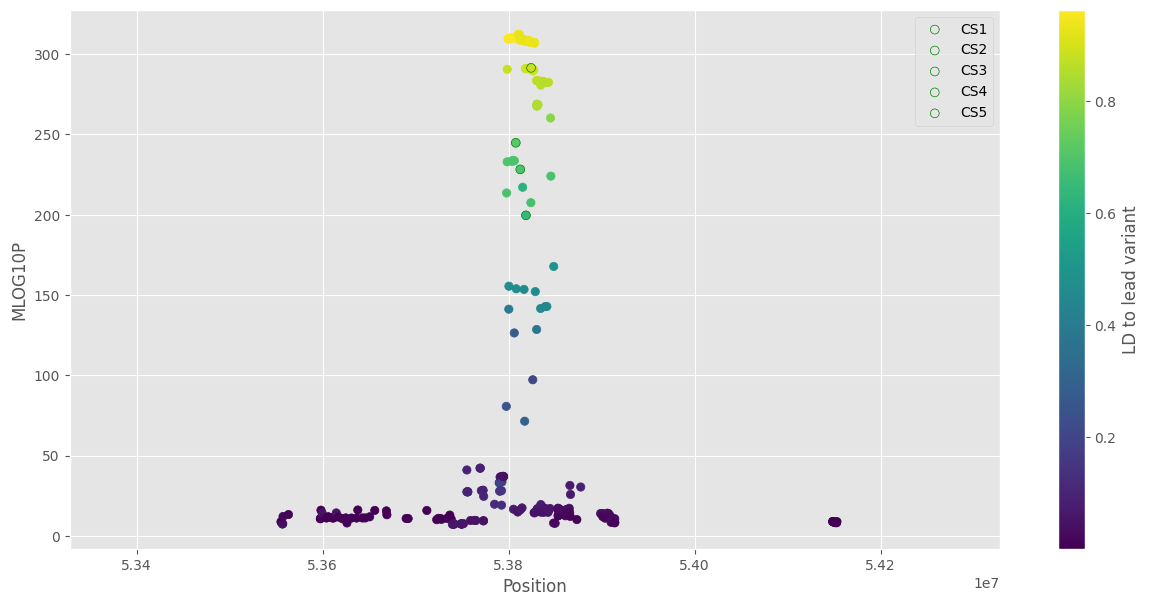

In [66]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))

col_to_plot = "MLOG10P"
filtered_chr16_pos53828066_region[col_to_plot] = -np.log10(filtered_chr16_pos53828066_region["P"].replace(0, np.nan))

p = ax.scatter(
    filtered_chr16_pos53828066_region["POS"], 
    filtered_chr16_pos53828066_region[col_to_plot], 
    c=ld2[filtered_chr16_pos53828066_region["P"].idxmin()]
)

lead_x = filtered_chr16_pos53828066_region.loc[filtered_chr16_pos53828066_region["P"].idxmin(), "POS"]
lead_y = filtered_chr16_pos53828066_region.loc[filtered_chr16_pos53828066_region["P"].idxmin(), col_to_plot]

ax.annotate(
    f"Lead Variant: {filtered_chr16_pos53828066_region.loc[filtered_chr16_pos53828066_region['P'].idxmin(), 'SNPID']}", 
    (lead_x, lead_y), 
    textcoords="offset points", xytext=(0, lead_y + 2), ha='center', fontsize=12
)

credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)[0]
n_cs = len(credible_sets)

for i in range(n_cs):
    cs_index = credible_sets[i]
    pos = filtered_chr16_pos53828066_region.loc[np.array(cs_index) - 1, "POS"]
    y = filtered_chr16_pos53828066_region.loc[np.array(cs_index) - 1, col_to_plot]
    ax.scatter(pos, y, marker='o', s=40, label=f"CS{i+1}", edgecolors="green", facecolors="none")

plt.colorbar(p, label="LD to lead variant")
ax.set_xlabel("Position")
ax.set_ylabel(col_to_plot)
ax.set_xlim((53328066, 54328066))
plt.legend()
plt.show()


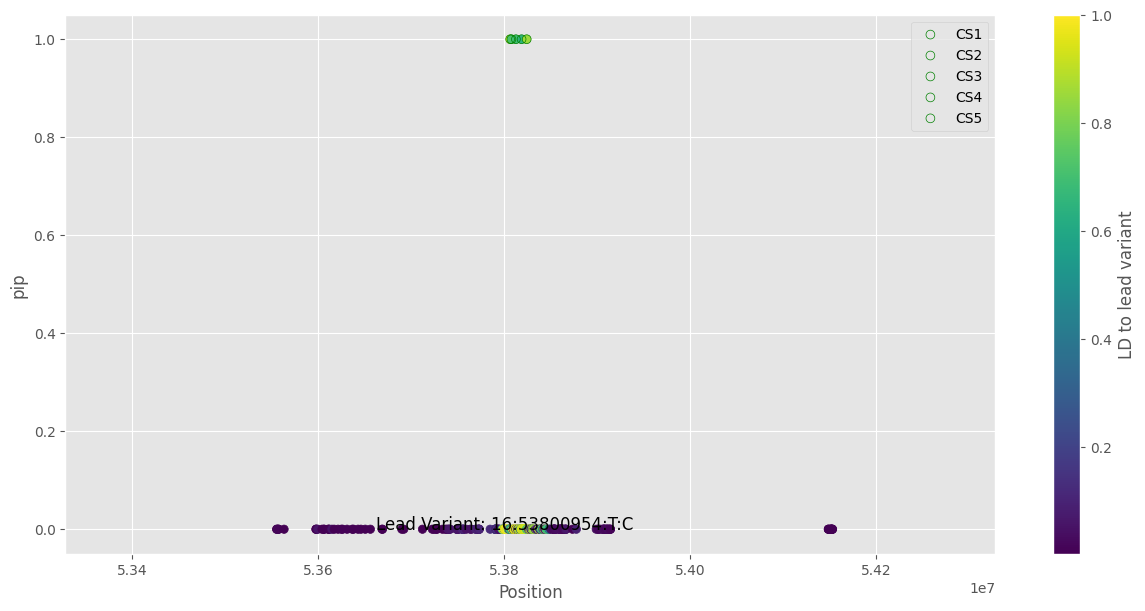

In [67]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))

col_to_plot = "pip"
p = ax.scatter(
    filtered_chr16_pos53828066_region["POS"], 
    filtered_chr16_pos53828066_region[col_to_plot], 
    c=ld2[filtered_chr16_pos53828066_region["P"].idxmin()]
)

lead_x = filtered_chr16_pos53828066_region.loc[filtered_chr16_pos53828066_region["P"].idxmin(), "POS"]
lead_y = filtered_chr16_pos53828066_region.loc[filtered_chr16_pos53828066_region["P"].idxmin(), col_to_plot]

ax.annotate(
    f"Lead Variant: {filtered_chr16_pos53828066_region.loc[filtered_chr16_pos53828066_region['P'].idxmin(), 'SNPID']}", 
    (lead_x, lead_y), 
    textcoords="offset points", xytext=(0, lead_y + 0.02), ha='center', fontsize=12
)

credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)[0]
n_cs = len(credible_sets)

for i in range(n_cs):
    cs_index = credible_sets[i]
    pos = filtered_chr16_pos53828066_region.loc[np.array(cs_index) - 1, "POS"]
    y = filtered_chr16_pos53828066_region.loc[np.array(cs_index) - 1, col_to_plot]
    
    ax.scatter(pos, y, marker='o', s=40, label=f"CS{i+1}", edgecolors="green", facecolors="none")

plt.colorbar(p, label="LD to lead variant")
ax.set_xlabel("Position")
ax.set_ylabel(col_to_plot)
ax.set_xlim((53328066, 54328066))
# ax.set_ylim((0, 0.1))
plt.legend()
plt.show()


## check LD of the causal variant and variants in the credible set 

In [ ]:
!echo "16:53812433:T:C  " > credible.snplist
!echo "16:53806453:A:G " >> credible.snplist
!echo "16:53813498:C:T " >> credible.snplist
!echo "16:53823727:T:C  " >> credible.snplist
!echo "16:53815435:T:C  " >> credible.snplist
!echo "16:53806145:T:C  " >> credible.snplist

In [ ]:
!plink \
  --bfile "../data/susie/plink_binary/merged_data" \
  --keep-allele-order \
  --r square \
  --extract credible.snplist \
  --out ../data/susie/ALL_chr/ld/credible_r

!plink \
  --bfile "../data/susie/plink_binary/merged_data" \
  --keep-allele-order \
  --r2 square \
  --extract credible.snplist \
  --out ../data/susie/ALL_chr/ld/credible_r2

PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ../data/susie/ALL_chr/ld/credible_r.log.
Options in effect:
  --bfile ../data/susie/plink_binary/merged_data
  --extract credible.snplist
  --keep-allele-order
  --out ../data/susie/ALL_chr/ld/credible_r
  --r square

257418 MB RAM detected; reserving 128709 MB for main workspace.
49063 variants loaded from .bim file.
503 people (0 males, 0 females, 503 ambiguous) loaded from .fam.
Ambiguous sex IDs written to ../data/susie/ALL_chr/ld/credible_r.nosex .
--extract: 6 variants remaining.
Using up to 27 threads (change this with --threads).
Before main variant filters, 503 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done

## Load LD and plot

In [ ]:
credible_snplist=["16:53812433:T:C ","16:53806453:A:G", "16:53813498:C:T", "16:53823727:T:C", "16:53815435:T:C", "16:53806145:T:C "]
ld = pd.read_csv("../data/susie/ALL_chr/ld/credible_r.ld",sep="\t",header=None)
ld.columns=credible_snplist
ld.index=credible_snplist
ld2 = pd.read_csv("../data/susie/ALL_chr/ld/credible_r2.ld",sep="\t",header=None)
ld2.columns=credible_snplist
ld2.index=credible_snplist

Text(0.5, 1.0, 'LD r2 matrix')

<Figure size 2000x2000 with 0 Axes>

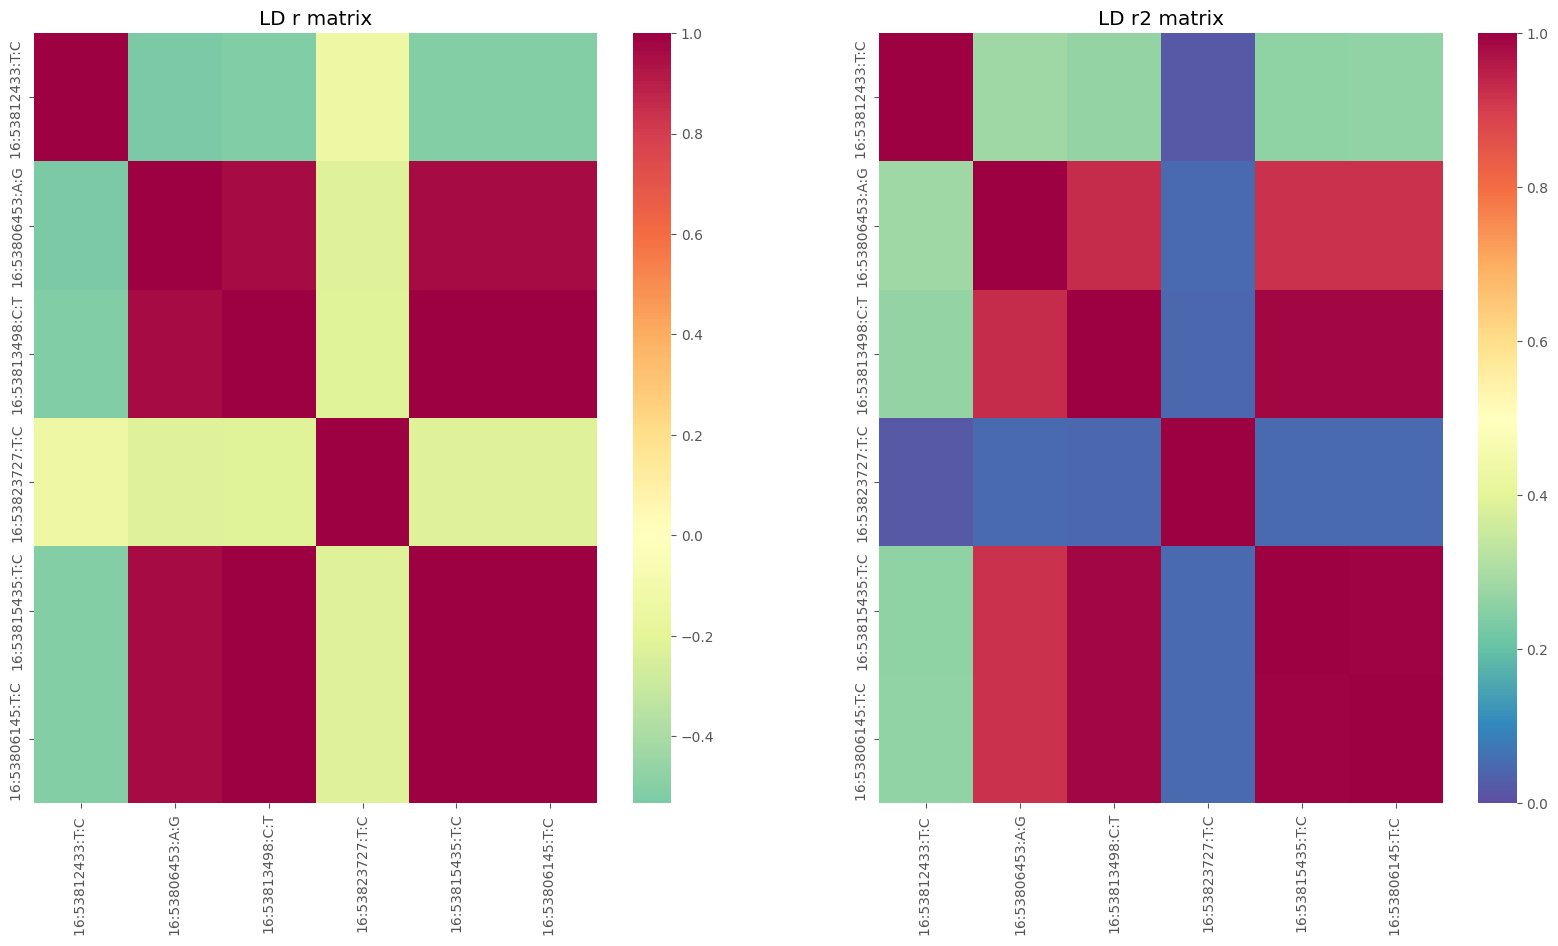

In [ ]:
plt.figure(figsize=(10,10),dpi=200)
fig, ax = plt.subplots(ncols=2,figsize=(20,10))
sns.heatmap(data=ld, cmap="Spectral_r",ax=ax[0],center=0)
sns.heatmap(data=ld2,cmap="Spectral_r",ax=ax[1],vmin=0,vmax=1)
ax[0].set_title("LD r matrix")
ax[1].set_title("LD r2 matrix")